# Module 2 — Advanced Classification
## Logistic Regression
**Dataset:** cmi_module1_clean-1.csv  
**Target:** sii (0=None, 1=Mild, 2=Moderate, 3=Severe)  
**Split:** 80/20 stratified, random_state=42  
**Imbalance handling:** class_weight tested via GridSearchCV (Balanced)

---
## Section 0 — Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# ── Load ─────────────────────────────────────────────────────────
df = pd.read_csv('cmi_module1_clean-1.csv')
print(f"Dataset shape: {df.shape}")

# ── Class distribution ───────────────────────────────────────────
print("\nsii class distribution:")
dist = df['sii'].value_counts().sort_index()
for cls, cnt in dist.items():
    print(f"  sii={int(cls)}: {cnt} ({cnt/len(df)*100:.1f}%)")

Dataset shape: (8417, 32)

sii class distribution:
  sii=0: 5807 (69.0%)
  sii=1: 1577 (18.7%)
  sii=2: 947 (11.3%)
  sii=3: 86 (1.0%)


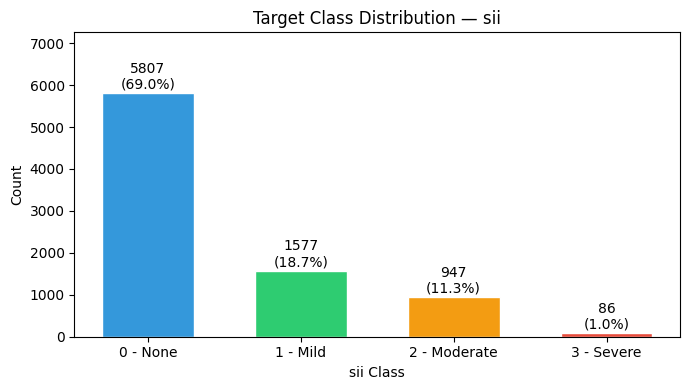

Imbalance ratio: 67.5x (majority/minority)


In [2]:
# ── Class distribution bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3498DB','#2ECC71','#F39C12','#E74C3C']
bars = ax.bar(
    ['0 - None','1 - Mild','2 - Moderate','3 - Severe'],
    dist.values, color=colors, edgecolor='white', width=0.6
)
for bar, cnt in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('sii Class')
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution — sii')
ax.set_ylim(0, dist.max() * 1.25)
plt.tight_layout()
plt.savefig('lr_class_distribution.png', dpi=150)
plt.show()
print(f"Imbalance ratio: {dist.max()/dist.min():.1f}x (majority/minority)")

---
## Section 1 — Feature Preparation & Train/Test Split

In [3]:
# ── Define features ──────────────────────────────────────────────
# Exclude target and categorical/ordinal columns not suitable for LR
exclude_cols = ['sii', 'ScreenTime_Category']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['sii'].astype(int)  # ensure integer labels

CLASSES     = [0, 1, 2, 3]
CLASS_NAMES = ['None', 'Mild', 'Moderate', 'Severe']

print(f"Features used: {len(feature_cols)}")
print(feature_cols)
print(f"\nTarget classes: {sorted(y.unique())}")

Features used: 30
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'FGC_Flexibility_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured', 'FGC_Muscular_Endurance', 'Social_Digital_Displacement', 'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count', 'ScreenTime_Age_Ratio']

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [4]:
# ── 80/20 stratified split ───────────────────────────────────────
# Stratified: ensures proportional sii class representation
# random_state=42: consistent across all team notebooks
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("\nTrain class distribution:")
for cls, cnt in y_train.value_counts().sort_index().items():
    print(f"  sii={cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")
print("\nTest class distribution:")
for cls, cnt in y_test.value_counts().sort_index().items():
    print(f"  sii={cls}: {cnt} ({cnt/len(y_test)*100:.1f}%)")

Train: 6733 rows | Test: 1684 rows

Train class distribution:
  sii=0: 4645 (69.0%)
  sii=1: 1261 (18.7%)
  sii=2: 758 (11.3%)
  sii=3: 69 (1.0%)

Test class distribution:
  sii=0: 1162 (69.0%)
  sii=1: 316 (18.8%)
  sii=2: 189 (11.2%)
  sii=3: 17 (1.0%)


In [5]:
# ── StandardScaler ───────────────────────────────────────────────
# Fit on training set ONLY to prevent data leakage
# Logistic Regression uses gradient descent — scaling is mandatory
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied — fit on training set only")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

StandardScaler applied — fit on training set only
X_train_scaled: (6733, 30)
X_test_scaled:  (1684, 30)


---
## Section 2 — Hyperparameter Tuning

**Parameters tuned:**
- `C` — regularisation strength. Small C = strong regularisation (simpler model). Large C = weak regularisation (fits training data more tightly).
- `multi_class` — `ovr` trains one binary classifier per class; `multinomial` trains one joint model using softmax across all classes.
- `class_weight` — `balanced` automatically weights classes inversely proportional to their frequency, penalising errors on minority classes (sii=3) more heavily.

**Fixed:** penalty=l2, solver=lbfgs (best compatibility with l2 + multinomial), max_iter=1000 (ensures convergence).

In [6]:
param_grid = {
    'C':            [0.01, 0.1, 1, 10, 100],
    'penalty':      ['l2'],
    'solver':       ['lbfgs'],
    'multi_class':  ['ovr', 'multinomial'],
    'class_weight': ['balanced'],
    'max_iter':     [1000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1 (weighted): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters found:
  C: 0.01
  class_weight: balanced
  max_iter: 1000
  multi_class: ovr
  penalty: l2
  solver: lbfgs

Best CV F1 (weighted): 0.5700


Top 10 parameter combinations:
 param_C param_multi_class param_class_weight  mean_test_score  std_test_score
    0.01               ovr           balanced         0.569961        0.007807
    0.10               ovr           balanced         0.565837        0.007279
  100.00               ovr           balanced         0.563907        0.006062
   10.00               ovr           balanced         0.563719        0.005909
    1.00               ovr           balanced         0.563192        0.006547
    0.01       multinomial           balanced         0.552333        0.004892
    0.10       multinomial           balanced         0.544413        0.006284
    1.00       multinomial           balanced         0.543494        0.008715
   10.00       multinomial           balanced         0.542841        0.009349
  100.00       multinomial           balanced         0.542755        0.009151


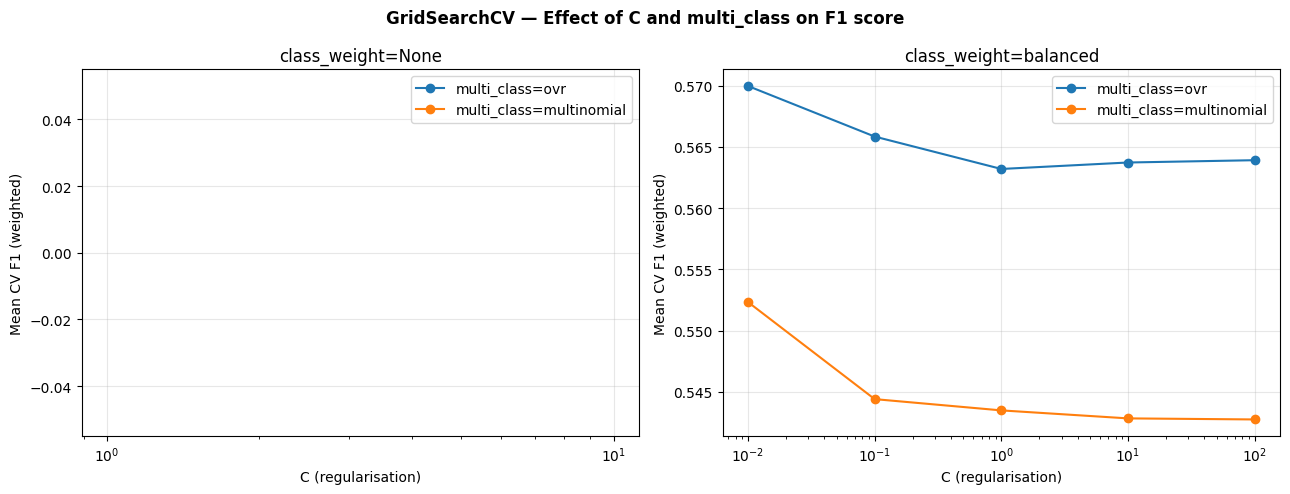

In [7]:
# ── GridSearch results analysis ──────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

print("Top 10 parameter combinations:")
cols = ['param_C','param_multi_class','param_class_weight',
        'mean_test_score','std_test_score']
print(cv_results[cols].head(10).to_string(index=False))

# ── Effect of C on CV score ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cw, title in zip(
    axes,
    [None, 'balanced'],
    ['class_weight=None', 'class_weight=balanced']
):
    for mc in ['ovr', 'multinomial']:
        subset = cv_results[
            (cv_results['param_class_weight'].astype(str) == str(cw)) &
            (cv_results['param_multi_class'] == mc)
        ].sort_values('param_C')
        ax.plot(
            subset['param_C'].astype(float),
            subset['mean_test_score'],
            marker='o', label=f'multi_class={mc}'
        )
    ax.set_xscale('log')
    ax.set_xlabel('C (regularisation)')
    ax.set_ylabel('Mean CV F1 (weighted)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('GridSearchCV — Effect of C and multi_class on F1 score',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_gridsearch_cv.png', dpi=150)
plt.show()

---
## Section 3 — Final Model Training & Evaluation

In [8]:
# ── Train best model ─────────────────────────────────────────────
best_lr = grid_search.best_estimator_

# Predict
y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)

# ── Metrics ──────────────────────────────────────────────────────
y_bin   = label_binarize(y_test, classes=CLASSES)
roc_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')

print("=" * 55)
print("LOGISTIC REGRESSION — TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\nBest parameters used:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

LOGISTIC REGRESSION — TEST SET RESULTS
  Accuracy:  0.5279
  Precision: 0.6227
  Recall:    0.5279
  F1-score:  0.5684
  ROC-AUC:   0.6897

Best parameters used:
  C: 0.01
  class_weight: balanced
  max_iter: 1000
  multi_class: ovr
  penalty: l2
  solver: lbfgs


In [9]:
# ── Classification report ────────────────────────────────────────
print("Classification Report (per-class breakdown):")
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

Classification Report (per-class breakdown):
              precision    recall  f1-score   support

        None       0.80      0.65      0.72      1162
        Mild       0.25      0.21      0.23       316
    Moderate       0.24      0.33      0.28       189
      Severe       0.02      0.24      0.03        17

    accuracy                           0.53      1684
   macro avg       0.33      0.36      0.31      1684
weighted avg       0.62      0.53      0.57      1684



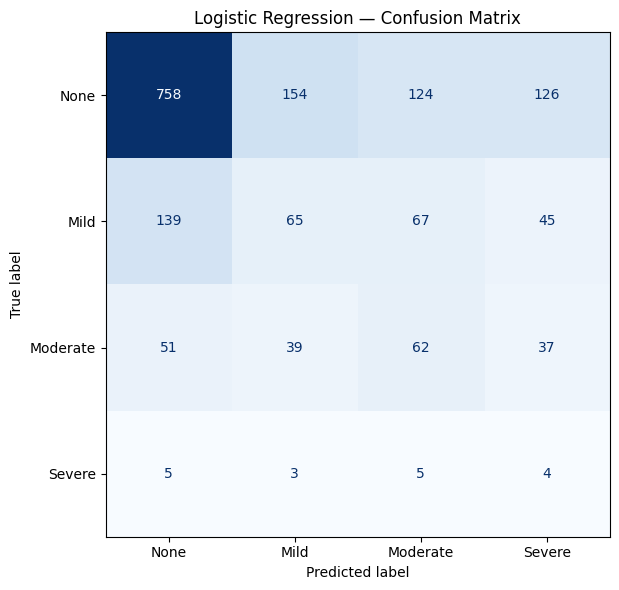

In [10]:
# ── Confusion matrix ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
ConfusionMatrixDisplay(
    cm, display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150)
plt.show()

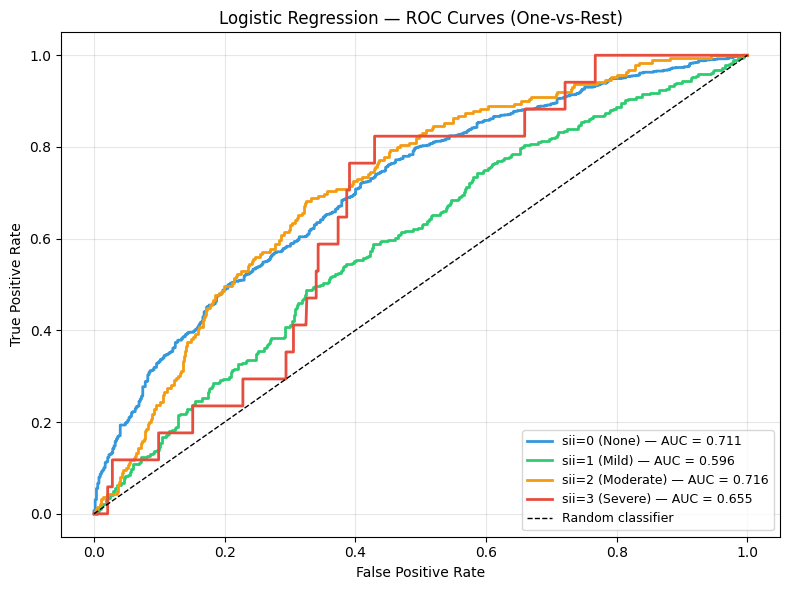

In [11]:
# ── ROC Curves — one per class (OvR) ────────────────────────────
colors = ['#3498DB','#2ECC71','#F39C12','#E74C3C']

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color, name) in enumerate(zip(CLASSES, colors, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'sii={cls} ({name}) — AUC = {roc_auc_cls:.3f}')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lr_roc_curves.png', dpi=150)
plt.show()

---
## Section 4 — Feature Analysis
Logistic Regression assigns a coefficient to each feature per class.  
Large positive coefficient → feature pushes prediction toward that class.  
Large negative coefficient → feature pushes away from that class.

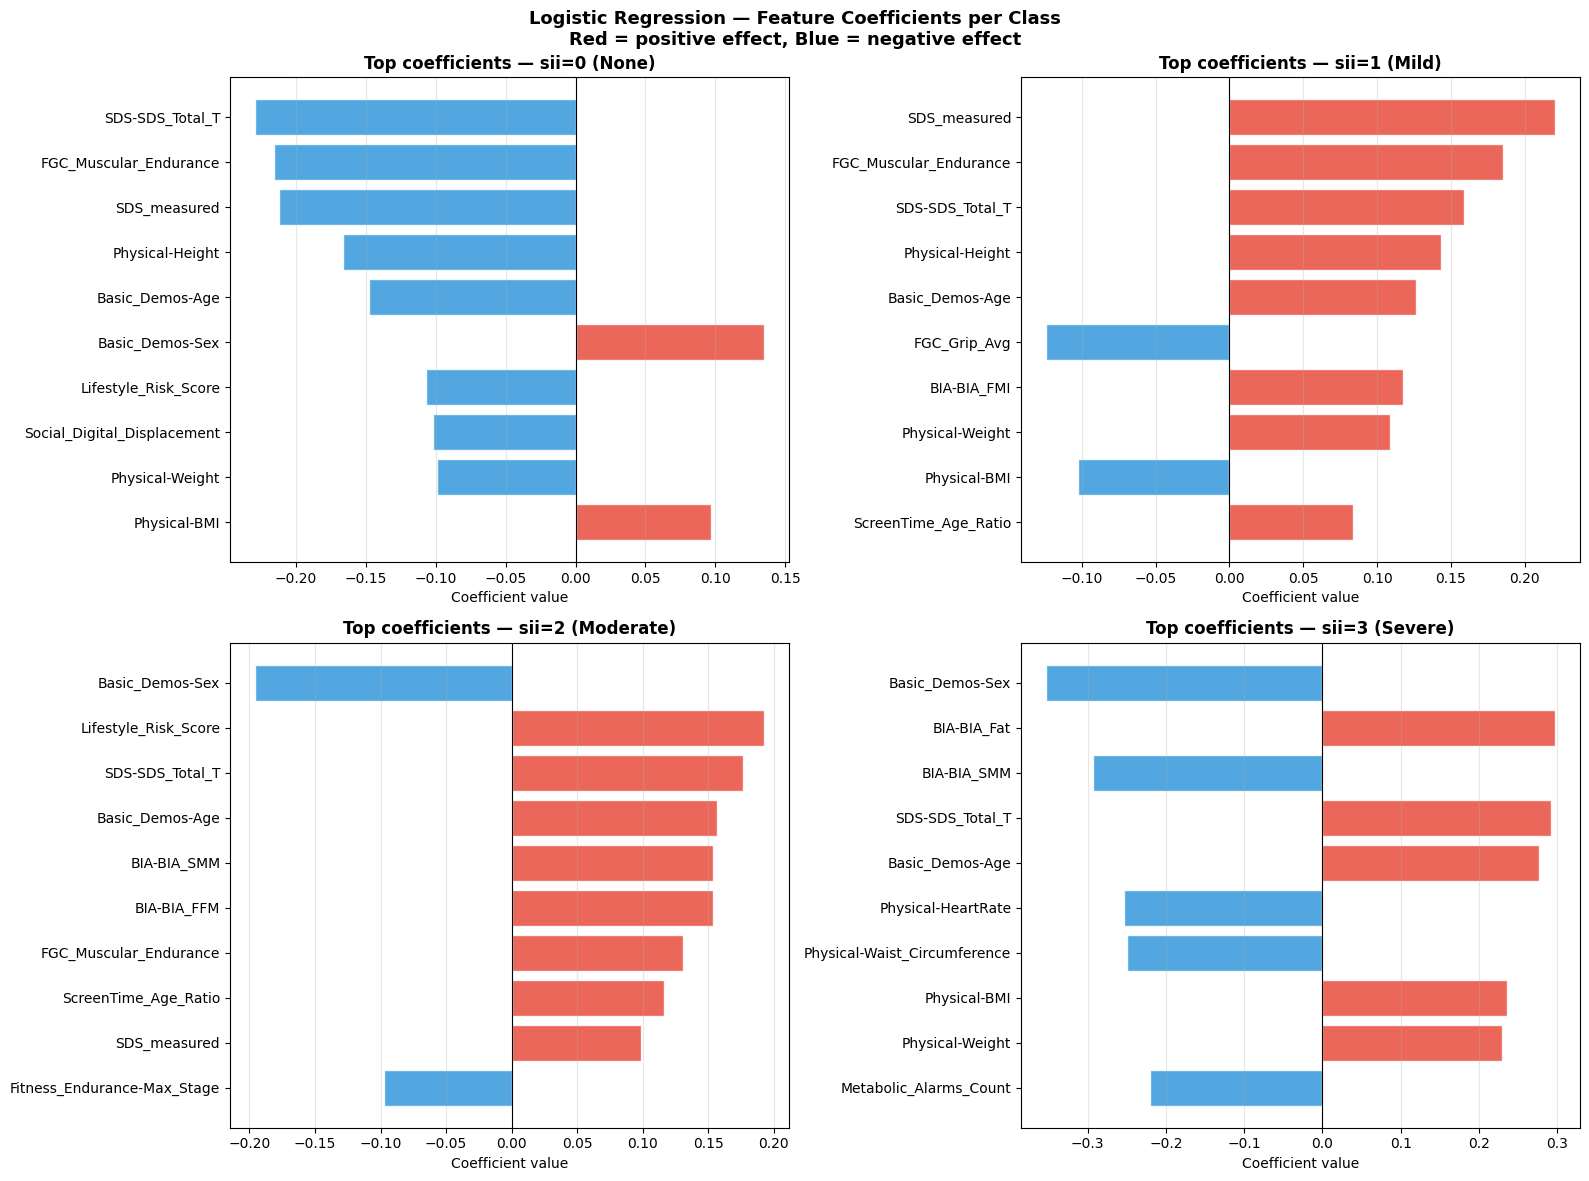

In [12]:
# ── Coefficient analysis ─────────────────────────────────────────
coef_df = pd.DataFrame(
    best_lr.coef_,
    index=[f'sii={c} ({n})' for c, n in zip(CLASSES, CLASS_NAMES)],
    columns=feature_cols
).T

# Top 10 most impactful features per class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, col in zip(axes.flatten(), coef_df.columns):
    top = coef_df[col].abs().nlargest(10).index
    vals = coef_df.loc[top, col]
    colors_bar = ['#E74C3C' if v > 0 else '#3498DB' for v in vals]
    ax.barh(top, vals, color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top coefficients — {col}', fontweight='bold')
    ax.set_xlabel('Coefficient value')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Logistic Regression — Feature Coefficients per Class\n'
             'Red = positive effect, Blue = negative effect',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150)
plt.show()

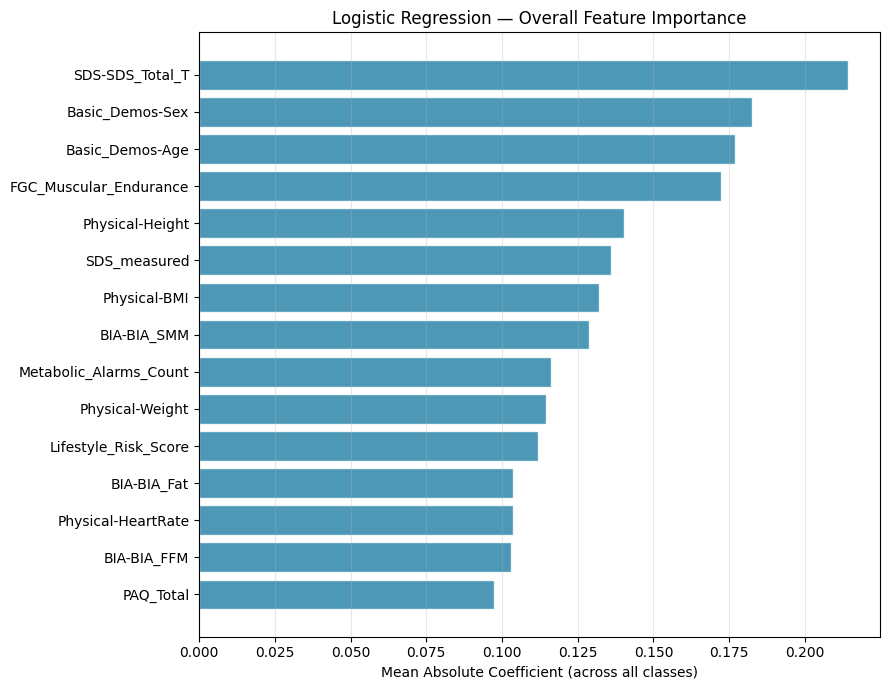

Top 10 most influential features:
SDS-SDS_Total_T           0.2141
Basic_Demos-Sex           0.1825
Basic_Demos-Age           0.1769
FGC_Muscular_Endurance    0.1722
Physical-Height           0.1402
SDS_measured              0.1360
Physical-BMI              0.1320
BIA-BIA_SMM               0.1286
Metabolic_Alarms_Count    0.1161
Physical-Weight           0.1147


In [13]:
# ── Overall feature importance (mean absolute coefficient) ───────
mean_abs_coef = coef_df.abs().mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    mean_abs_coef.index[:15],
    mean_abs_coef.values[:15],
    color='#2E86AB', alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Mean Absolute Coefficient (across all classes)')
ax.set_title('Logistic Regression — Overall Feature Importance')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150)
plt.show()

print("Top 10 most influential features:")
print(mean_abs_coef.head(10).round(4).to_string())

---
## Section 5 — Model Comparison (class_weight effect)
Compare best model vs same model without class weighting to show the impact of handling imbalance.

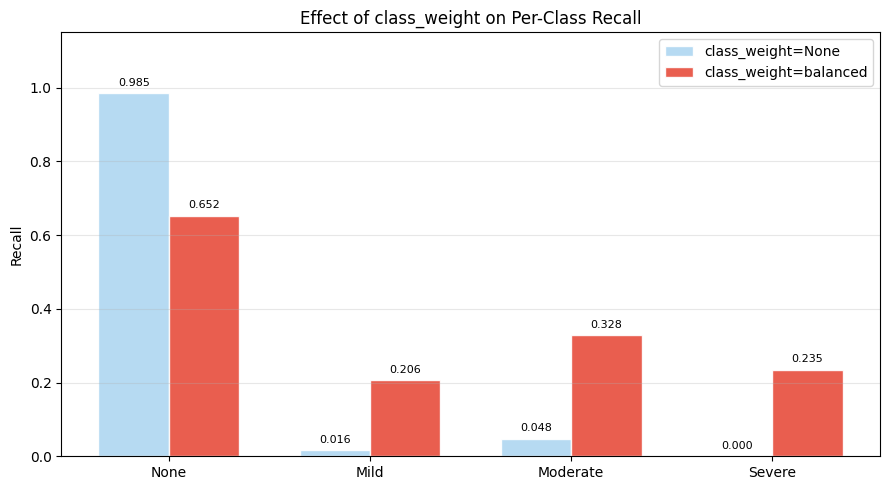


Recall comparison per class:
  None: None=0.9845 | balanced=0.6523
  Mild: None=0.0158 | balanced=0.2057
  Moderate: None=0.0476 | balanced=0.3280
  Severe: None=0.0000 | balanced=0.2353


In [14]:
# ── Compare class_weight=None vs balanced ────────────────────────
best_params_no_cw = {k: v for k, v in grid_search.best_params_.items()
                     if k != 'class_weight'}
best_params_no_cw['class_weight'] = None

lr_no_cw = LogisticRegression(**best_params_no_cw)
lr_no_cw.fit(X_train_scaled, y_train)
y_pred_no_cw = lr_no_cw.predict(X_test_scaled)

best_params_bal = {k: v for k, v in grid_search.best_params_.items()
                   if k != 'class_weight'}
best_params_bal['class_weight'] = 'balanced'

lr_bal = LogisticRegression(**best_params_bal)
lr_bal.fit(X_train_scaled, y_train)
y_pred_bal = lr_bal.predict(X_test_scaled)

# Per-class recall comparison
from sklearn.metrics import recall_score
recall_none = recall_score(y_test, y_pred_no_cw, labels=CLASSES,
                           average=None, zero_division=0)
recall_bal  = recall_score(y_test, y_pred_bal,   labels=CLASSES,
                           average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(4)
width = 0.35
ax.bar(x - width/2, recall_none, width, label='class_weight=None',
       color='#AED6F1', edgecolor='white', alpha=0.9)
ax.bar(x + width/2, recall_bal,  width, label='class_weight=balanced',
       color='#E74C3C', edgecolor='white', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('Effect of class_weight on Per-Class Recall')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (vn, vb) in enumerate(zip(recall_none, recall_bal)):
    ax.text(i - width/2, vn + 0.02, f'{vn:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, vb + 0.02, f'{vb:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('lr_classweight_comparison.png', dpi=150)
plt.show()

print("\nRecall comparison per class:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: None={recall_none[i]:.4f} | balanced={recall_bal[i]:.4f}")

---
## Section 6 — Per-Class Recall Heatmap

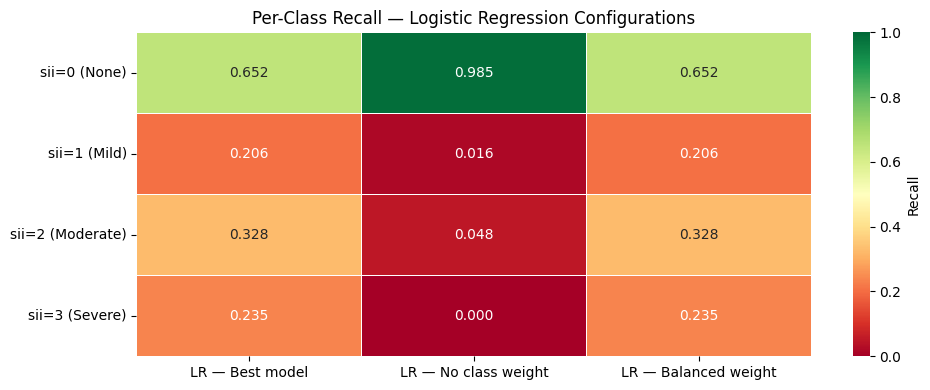

sii=3 (Severe) is the hardest class — focus on this row.


In [15]:
# ── Per-class recall heatmap ─────────────────────────────────────
from sklearn.metrics import recall_score as rec

configs = [
    ('LR — Best model', y_pred),
    ('LR — No class weight', y_pred_no_cw),
    ('LR — Balanced weight', y_pred_bal),
]

per_class = {}
for label, y_p in configs:
    per_class[label] = rec(y_test, y_p, labels=CLASSES,
                           average=None, zero_division=0)

recall_heatmap = pd.DataFrame(
    per_class,
    index=['sii=0 (None)','sii=1 (Mild)',
           'sii=2 (Moderate)','sii=3 (Severe)']
)

plt.figure(figsize=(10, 4))
sns.heatmap(recall_heatmap, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Recall'})
plt.title('Per-Class Recall — Logistic Regression Configurations')
plt.tight_layout()
plt.savefig('lr_recall_heatmap.png', dpi=150)
plt.show()
print("sii=3 (Severe) is the hardest class — focus on this row.")

---
## Section 7 — Summary & Conclusions

In [16]:
# ── Final summary ────────────────────────────────────────────────
y_bin = label_binarize(y_test, classes=CLASSES)
y_prob_final = best_lr.predict_proba(X_test_scaled)

print("=" * 60)
print("LOGISTIC REGRESSION — FINAL SUMMARY")
print("=" * 60)
print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print(f"\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_bin, y_prob_final, multi_class='ovr', average='weighted'):.4f}")

print(f"\nPer-class recall:")
per_cls_recall = recall_score(y_test, y_pred, labels=CLASSES,
                              average=None, zero_division=0)
for cls, name, r in zip(CLASSES, CLASS_NAMES, per_cls_recall):
    print(f"  sii={cls} ({name}): {r:.4f}")

print(f"\nKey observations:")
print(f"  - C={grid_search.best_params_['C']} selected: ", end='')
if grid_search.best_params_['C'] <= 0.1:
    print("strong regularisation — model prefers simpler boundary")
elif grid_search.best_params_['C'] >= 10:
    print("weak regularisation — model fits training data tightly")
else:
    print("moderate regularisation — balanced bias-variance tradeoff")

print(f"  - multi_class={grid_search.best_params_['multi_class']}: ", end='')
if grid_search.best_params_['multi_class'] == 'multinomial':
    print("softmax across all classes outperforms binary OvR")
else:
    print("OvR binary classifiers outperform joint multinomial model")

print(f"  - class_weight={grid_search.best_params_['class_weight']}: ", end='')
if grid_search.best_params_['class_weight'] == 'balanced':
    print("balancing class weights improved minority class detection")
else:
    print("no class weighting selected — majority class dominates")

print(f"  - sii=3 (Severe) recall = {per_cls_recall[3]:.4f} — ", end='')
if per_cls_recall[3] < 0.3:
    print("model struggles with severe cases — expected for LR on nonlinear data")
else:
    print("reasonable minority class detection achieved")

LOGISTIC REGRESSION — FINAL SUMMARY

Best parameters:
  C: 0.01
  class_weight: balanced
  max_iter: 1000
  multi_class: ovr
  penalty: l2
  solver: lbfgs

Test Set Performance:
  Accuracy:  0.5279
  Precision: 0.6227
  Recall:    0.5279
  F1-score:  0.5684
  ROC-AUC:   0.6897

Per-class recall:
  sii=0 (None): 0.6523
  sii=1 (Mild): 0.2057
  sii=2 (Moderate): 0.3280
  sii=3 (Severe): 0.2353

Key observations:
  - C=0.01 selected: strong regularisation — model prefers simpler boundary
  - multi_class=ovr: OvR binary classifiers outperform joint multinomial model
  - class_weight=balanced: balancing class weights improved minority class detection
  - sii=3 (Severe) recall = 0.2353 — model struggles with severe cases — expected for LR on nonlinear data
